# Modelling

## Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

In [2]:
df_train = pd.read_csv('../data/processed/preprocessed_model_v1/train_processed.csv')
df_val = pd.read_csv('../data/processed/preprocessed_model_v1/val_processed.csv')
df_test = pd.read_csv('../data/processed/preprocessed_model_v1/test_processed.csv')

In [3]:
# data structure to save evaluation results from different models
model_evaluation_results = {}

In [4]:
def check_feature_statistics(x_columns, data):
    print(f"--- Running Statistical Analysis for {len(x_columns)} features ---")
    
    X = sm.add_constant(data[x_columns])
    y = data['Churn']
    
    try:
        stat_model = sm.Logit(y, X).fit(disp=False)

        print(stat_model.summary())
        
        p_values = stat_model.pvalues.reset_index()
        p_values.columns = ['Feature', 'P-Value']
        p_values['Is_Significant'] = p_values['P-Value'] < 0.05
        
        return p_values.sort_values(by='P-Value')
        
    except Exception as e:
        print(f"Model failed to converge: {e}")

## Check P-Values for All Features

In [5]:
feature_stats = check_feature_statistics(df_train.columns.drop('Churn').tolist(), df_train)

--- Running Statistical Analysis for 26 features ---
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 4930
Model:                          Logit   Df Residuals:                     4904
Method:                           MLE   Df Model:                           25
Date:                Sun, 07 Jun 2026   Pseudo R-squ.:                  0.2652
Time:                        16:00:56   Log-Likelihood:                -2095.7
converged:                       True   LL-Null:                       -2852.2
Covariance Type:            nonrobust   LLR p-value:                2.635e-304
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -1.5841      0.284     -5.581      0.000      -2.140      -1.0

In [6]:
non_significant = feature_stats[feature_stats['Is_Significant'] == False]['Feature'].tolist()
non_significant

['StreamingTV_Yes',
 'gender_Unknown',
 'SeniorCitizen',
 'PaymentMethod_Mailed check',
 'OnlineBackup',
 'StreamingTV_Unknown',
 'PhoneService',
 'DeviceProtection',
 'gender_Male',
 'Partner_Yes',
 'MonthlyCharges',
 'PaymentMethod_Credit card (automatic)',
 'InternetService_Unknown',
 'Partner_Unknown']

## Supporting Functions

In [7]:
def find_best_threshold(y_true, y_scores):
    
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    best_index = np.argmax(f1_scores)
    best_threshold = thresholds[best_index]
    
    return best_threshold

In [8]:
def build_logistic_regression_model(x_columns, data=df_train, val_data=df_val, threshold=None):
    
    model = LogisticRegression(
            class_weight='balanced', 
            max_iter=1000,
            l1_ratio=1, 
            solver='liblinear'
    ).fit(data[x_columns], data['Churn'])

    train_proba = model.predict_proba(data[x_columns])[:, 1]
    
    if threshold is None:
        threshold = find_best_threshold(data['Churn'], train_proba)
        
    predictions_proba = model.predict_proba(val_data[x_columns])[:, 1]
    predicted_classes = (predictions_proba >= threshold).astype(int)

    recall = recall_score(val_data['Churn'], predicted_classes)
    precision = precision_score(val_data['Churn'], predicted_classes)
    f1_score_val = f1_score(val_data['Churn'], predicted_classes)
    roc_auc = roc_auc_score(val_data['Churn'], predictions_proba)
    
    print("-------- Model Evaluation: --------")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1_score_val:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

    cm = confusion_matrix(val_data['Churn'], predicted_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

    evals = {
        'Recall': f"{recall:.4f}",
        'Precision': f"{precision:.4f}",
        'F1 Score': f"{f1_score_val:.4f}",
        'ROC_AUC': f"{roc_auc:.4f}"
        }
    
    return evals 

## Baseline Models

### 1. All the Features

To start, I am going to do the 1st baseline model with all the features. The idea is setting up a starting point that gives a clear point of comparison, and it allows checking if feature selecting improves the model in any significant way.

-------- Model Evaluation: --------
Recall: 0.7321
F1 Score: 0.6165
Precision: 0.5325
ROC AUC: 0.8263


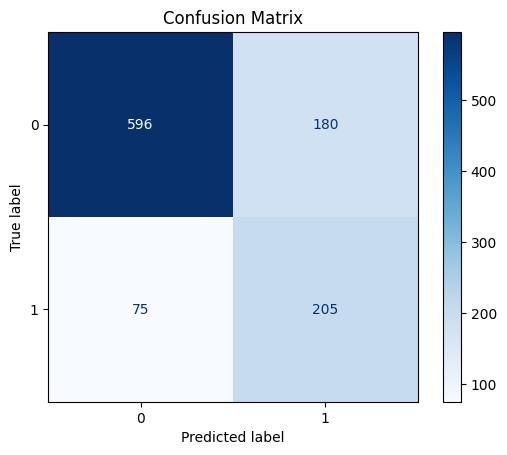

In [9]:
columns_model_1= df_train.columns.drop('Churn').tolist()
model_result_1 = build_logistic_regression_model(columns_model_1, df_train, df_val)

model_evaluation_results['model_1'] = model_result_1

### 2. Remove Gender and Partner

During the correlation analysis, we saw that `Partner` and `Gender` were columns that didn't seem to have any sort of impact with `Churn`. Looking at the p-values in our initial all-feature model this seems to be the case.

Let's remove them from the column selection and see how the evaluation metrics change.

-------- Model Evaluation: --------
Recall: 0.7464
F1 Score: 0.6174
Precision: 0.5264
ROC AUC: 0.8267


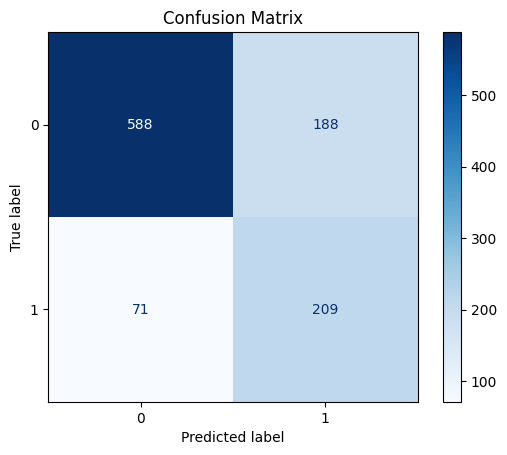

In [10]:
columns_model_2 = df_train.columns.drop(
    ['Churn', 'gender_Male', 'gender_Unknown', 'Partner_Yes', 'Partner_Unknown']
    ).tolist()

model_result_2 = build_logistic_regression_model(columns_model_2, df_train, df_val)
model_evaluation_results['model_2'] = model_result_2

As we can see there is a slight improvement of both Recall and Precision, which could mean the variables removed were limiting the performance of the model.

### 3. Removing StreamingTV

For this attempt, I will follow the same logic as Model 2, by removing the `StreamingTV` feature that was detected as non-relevant during correlation analysis and confirmed by looking at p-value.

-------- Model Evaluation: --------
Recall: 0.7250
F1 Score: 0.6142
Precision: 0.5328
ROC AUC: 0.8250


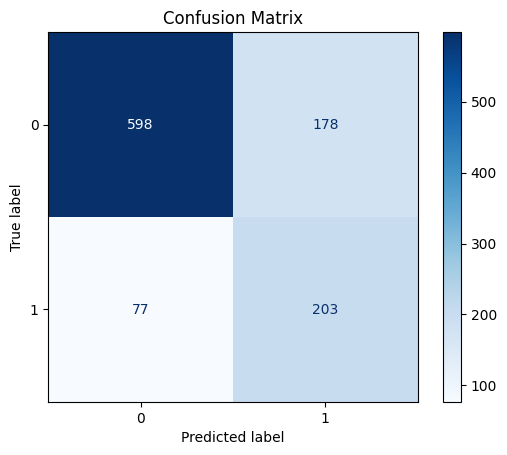

In [11]:
columns_model_3 = df_train.columns.drop(
    ['Churn', 'gender_Male', 'gender_Unknown', 'Partner_Yes', 'Partner_Unknown', 'StreamingTV_Yes', 'StreamingTV_Unknown']
    ).tolist()

model_result_3 = build_logistic_regression_model(columns_model_3, df_train, df_val)
model_evaluation_results['model_3'] = model_result_3

### 4. Removing Tenure and MonthlyCharges

In our analysis, it was found that it would be interesting to check how the model behaves in 2 scenarios:
1. With `tenure` and `MonthlyCharges`
2. With only `TotalCharges`

For this attempt I will be removing both `tenure` and `MonthlyCharges` to see how the model performs.

-------- Model Evaluation: --------
Recall: 0.7143
F1 Score: 0.6088
Precision: 0.5305
ROC AUC: 0.8232


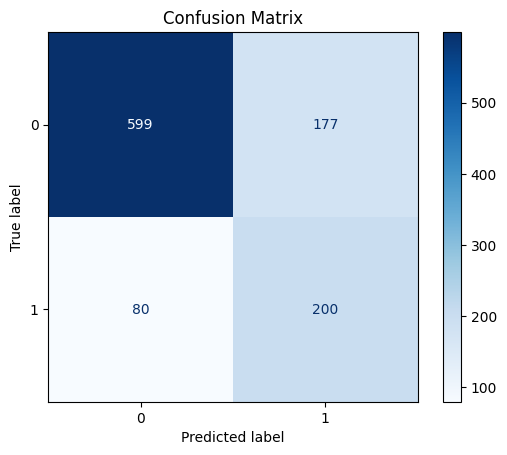

In [12]:
columns_model_4 = df_train.columns.drop(
    ['Churn', 'gender_Male', 'gender_Unknown', 'Partner_Yes', 'Partner_Unknown', 'StreamingTV_Yes', 'StreamingTV_Unknown',
     'tenure', 'MonthlyCharges']
    ).tolist()

model_result_4 = build_logistic_regression_model(columns_model_4, df_train, df_val)
model_evaluation_results['model_4'] = model_result_4

For this attempt, the model raises Precision considerable but the all other metrics get lower, which indicated that taking them out might not be a good idea. 

### 5. Removing Contract and TotalCharges

Since `tenure` and `Contract` seem to be measuring the same thing, I will continue the analysis of the last model and remove `Contract` and `TotalCharges` and see how the model performs.

-------- Model Evaluation: --------
Recall: 0.7607
F1 Score: 0.5788
Precision: 0.4671
ROC AUC: 0.7986


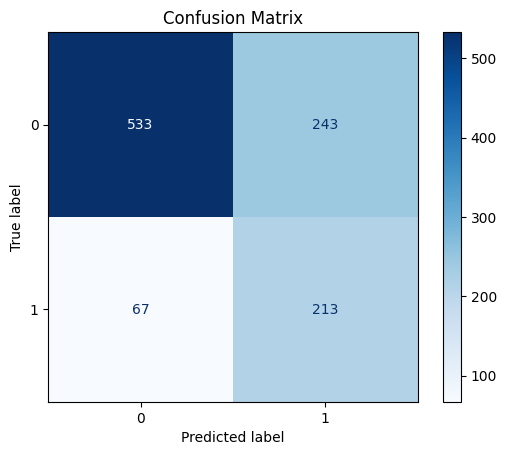

In [13]:
columns_model_5 = df_train.columns.drop(
    ['Churn', 'gender_Male', 'gender_Unknown', 'Partner_Yes', 'Partner_Unknown', 'StreamingTV_Yes', 'StreamingTV_Unknown',
     'TotalCharges', 'Contract']
    ).tolist()

model_result_5 = build_logistic_regression_model(columns_model_5, df_train, df_val)
model_evaluation_results['model_5'] = model_result_5

The results of this model also get lower which means that `Contract` and `TotalCharges` are important features of our model and should not be taken out.

### 6. Removing Services

In our correlation analysis we also saw that some services don't seem to have any strong impact in `Churn`, this combined with p-value analysis, make `DeviceProtection`, `PhoneService` and `OnlineBackup` strong candidates of removal. 

-------- Model Evaluation: --------
Recall: 0.7214
F1 Score: 0.6103
Precision: 0.5288
ROC AUC: 0.8245


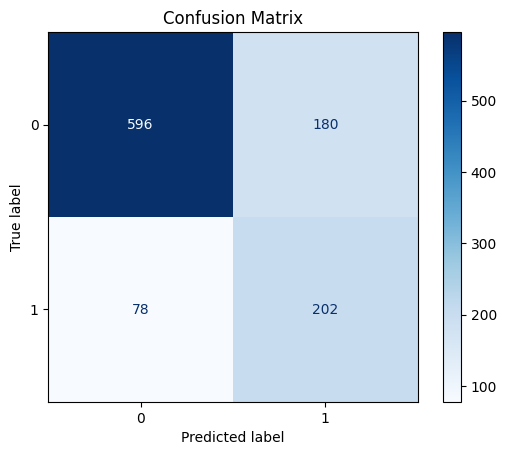

In [14]:
columns_model_6 = df_train.columns.drop(
    ['Churn', 'gender_Male', 'gender_Unknown', 'Partner_Yes', 'Partner_Unknown', 'StreamingTV_Yes', 'StreamingTV_Unknown',
     'DeviceProtection', 'PhoneService', 'OnlineBackup']
    ).tolist()

model_result_6 = build_logistic_regression_model(columns_model_6, df_train, df_val)
model_evaluation_results['model_6'] = model_result_6

Taking the selected features out makes the results better but it ends up not beating the best evaluation scores.

## Baseline Selection and Testing

In [15]:
model_evaluation_results_df = pd.DataFrame(model_evaluation_results).T
model_evaluation_results_df

,Recall,Precision,F1 Score,ROC_AUC
model_1,0.7321,0.5325,0.6165,0.8263
model_2,0.7464,0.5264,0.6174,0.8267
model_3,0.7250,0.5328,0.6142,0.8250
model_4,0.7143,0.5305,0.6088,0.8232
model_5,0.7607,0.4671,0.5788,0.7986
model_6,0.7214,0.5288,0.6103,0.8245


-------- Model Evaluation: --------
Recall: 0.6940
F1 Score: 0.6132
Precision: 0.5493
ROC AUC: 0.8279


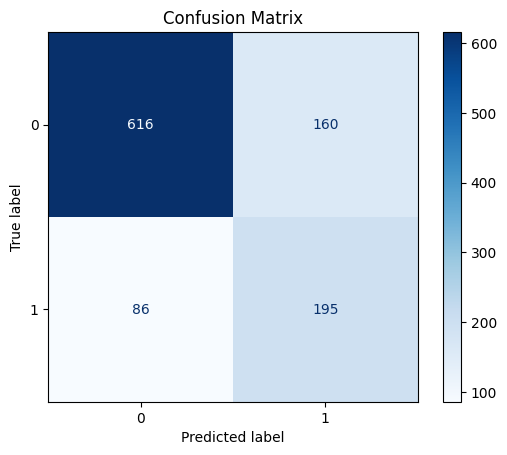

In [16]:
# test model 6 on test set
final_model_columns = columns_model_2

chosen_model = build_logistic_regression_model(final_model_columns, df_train, df_test)

## PCA

In [17]:
X_train_pca = df_train[columns_model_2]  # use your best model's features
X_val_pca   = df_val[columns_model_2] 
X_test_pca  = df_test[columns_model_2] 

pca = PCA(random_state=42)
pca.fit(X_train_pca) 

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

### Scree Plot

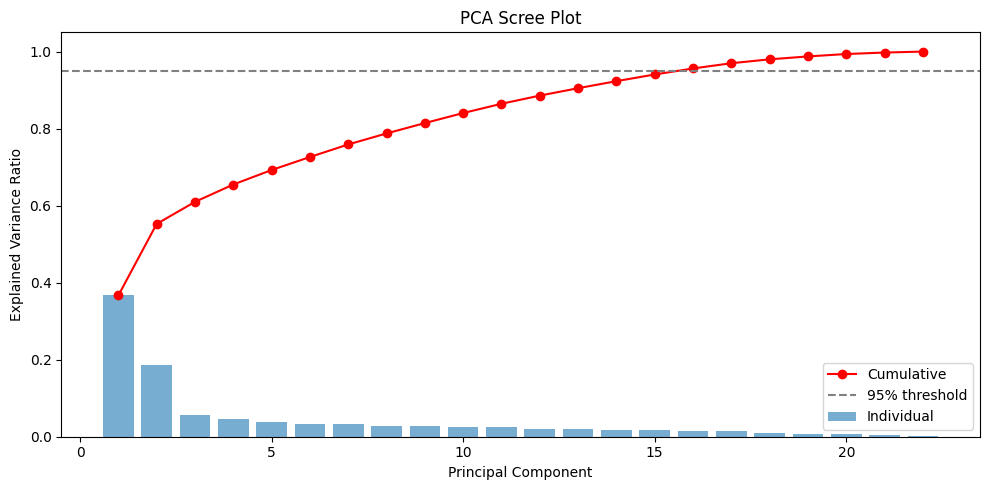

Components needed for 95% variance: 16
Total features: 17


In [18]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained) + 1), explained, alpha=0.6, label='Individual')
ax.plot(range(1, len(explained) + 1), cumulative, marker='o', color='red', label='Cumulative')
ax.axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Scree Plot')
ax.legend()
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")
print(f"Total features: {len(columns_model_6)}")

### Building Model with PCA

-------- Model Evaluation: --------
Recall: 0.6929
F1 Score: 0.5978
Precision: 0.5257
ROC AUC: 0.8202


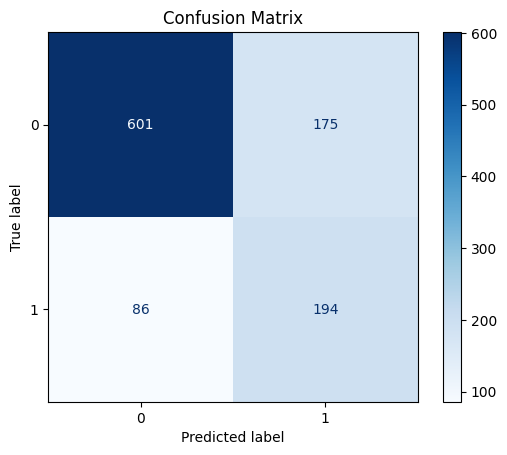

In [19]:
pca_final = PCA(n_components=n_components_95, random_state=42)

X_train_transformed = pca_final.fit_transform(X_train_pca)
X_val_transformed   = pca_final.transform(X_val_pca)
X_test_transformed  = pca_final.transform(X_test_pca)

pca_columns = [f'PC{i+1}' for i in range(n_components_95)]

df_train_pca = pd.DataFrame(X_train_transformed, columns=pca_columns)
df_val_pca   = pd.DataFrame(X_val_transformed,   columns=pca_columns)
df_test_pca  = pd.DataFrame(X_test_transformed,  columns=pca_columns)

df_train_pca['Churn'] = df_train['Churn'].values
df_val_pca['Churn']   = df_val['Churn'].values
df_test_pca['Churn']  = df_test['Churn'].values

pca_model = build_logistic_regression_model(pca_columns, df_train_pca, df_val_pca)
model_evaluation_results['pca_model'] = pca_model

In [20]:
model_evaluation_results_df = pd.DataFrame(model_evaluation_results)
model_evaluation_results_df[['model_2', 'pca_model']].T

,Recall,Precision,F1 Score,ROC_AUC
model_2,0.7464,0.5264,0.6174,0.8267
pca_model,0.6929,0.5257,0.5978,0.8202


### Component Interpretability

In [21]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=columns_model_2,
    columns=pca_columns
)
print(loadings['PC1'].sort_values(key=abs, ascending=False).head(10))

TotalCharges        0.576378
MonthlyCharges      0.453472
tenure              0.451491
Contract            0.226872
StreamingMovies     0.176645
DeviceProtection    0.167962
OnlineBackup        0.156851
MultipleLines       0.154259
StreamingTV_Yes     0.153752
TechSupport         0.130993
Name: PC1, dtype: float64


In [22]:
print(loadings['PC2'].sort_values(key=abs, ascending=False).head(10))

MonthlyCharges                    0.533295
Contract                         -0.531266
tenure                           -0.430797
InternetService_Fiber optic       0.257028
PaymentMethod_Electronic check    0.208037
InternetService_No               -0.198506
PaperlessBilling                  0.164388
Dependents                       -0.116332
StreamingTV_Yes                   0.111227
StreamingMovies                   0.109089
Name: PC2, dtype: float64
